# Risk-Return Analysis of Indian Stocks
### Final Year Project
**Stocks:** TCS · Sun Pharma · Mahindra & Mahindra (M&M)  
**Period:** April 2016 – April 2026 (10 Years)  
**Exchange:** NSE (National Stock Exchange of India)

---

## Business Questions

| # | Question |
|---|----------|
| **BQ1** | Which stock delivered the highest return over the 10-year period (2016–2026) — in terms of both Annual Return and CAGR? |
| **BQ2** | Which stock carries the least risk based on Annual Volatility and Maximum Drawdown from peak price? |
| **BQ3** | Which stock provides the best risk-adjusted return as measured by the Sharpe Ratio? |
| **BQ4** | How correlated are TCS, Sun Pharma, and M&M in terms of daily returns — and what does this mean for portfolio diversification? |
| **BQ5** | Which stock is most suitable for a conservative investor vs an aggressive investor? |

---
## Step 1: Imports & Configuration

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

CHARTS_DIR = 'charts'
DATA_DIR   = 'data'
os.makedirs(CHARTS_DIR, exist_ok=True)

COLORS = {'TCS': '#378ADD', 'SUNPHARMA': '#E8874A', 'M&M': '#4CAF7D'}
RISK_FREE_ANNUAL = 0.065   # RBI repo rate benchmark 6.5%
RISK_FREE_DAILY  = RISK_FREE_ANNUAL / 252

print("Configuration done. Charts will be saved in:", CHARTS_DIR)

Configuration done. Charts will be saved in: charts


---
## Step 2: Load Data

In [21]:
tcs = pd.read_csv(os.path.join(DATA_DIR, 'TCS_10y.csv'))
sun = pd.read_csv(os.path.join(DATA_DIR, 'SUNPHARMA_10y.csv'))
mm  = pd.read_csv(os.path.join(DATA_DIR, 'MM_10years_data.csv'))

print(f"TCS      : {tcs.shape[0]:,} rows")
print(f"SUNPHARMA: {sun.shape[0]:,} rows")
print(f"M&M      : {mm.shape[0]:,} rows")

# Preview TCS data
tcs.head()

TCS      : 2,470 rows
SUNPHARMA: 2,470 rows
M&M      : 2,470 rows


,Date,Open,High,Low,Close,Volume,Adj_Close
0,2016-04-04,971.412196,984.069033,967.852461,977.443970,1752352,977.443970
1,2016-04-05,977.266159,982.843020,965.894780,974.082153,1491794,974.082153
2,2016-04-06,976.949406,984.464402,972.737092,981.656128,1763150,981.656128
3,2016-04-07,980.904935,982.763889,971.807833,977.266113,2390942,977.266113
4,2016-04-08,975.367424,978.412956,959.941905,961.939331,1399500,961.939331


---
## Step 3: Clean Data

In [22]:
def clean_df(df, name):
    """Clean raw stock dataframe — fix columns, parse dates, drop nulls."""
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    nulls = df.isnull().sum().sum()
    df = df.drop_duplicates().dropna()
    df = df.sort_values('date').reset_index(drop=True)
    print(f"{name:10s} — nulls dropped: {nulls} | shape: {df.shape} | "
          f"{df['date'].iloc[0].date()} to {df['date'].iloc[-1].date()}")
    return df

tcs = clean_df(tcs, 'TCS')
sun = clean_df(sun, 'SUNPHARMA')
mm  = clean_df(mm,  'M&M')

TCS        — nulls dropped: 0 | shape: (2470, 7) | 2016-04-04 to 2026-04-02
SUNPHARMA  — nulls dropped: 0 | shape: (2470, 7) | 2016-04-04 to 2026-04-02
M&M        — nulls dropped: 0 | shape: (2470, 7) | 2016-04-04 to 2026-04-02


---
## Step 4: Calculate Daily Returns

In [23]:
for df in [tcs, sun, mm]:
    df['daily_return'] = df['adj_close'].pct_change()

print("Daily returns calculated for all 3 stocks.")
tcs[['date', 'adj_close', 'daily_return']].tail(5)

Daily returns calculated for all 3 stocks.


,date,adj_close,daily_return
2465,2026-03-25,2377.399902,-0.008921
2466,2026-03-27,2389.800049,0.005216
2467,2026-03-30,2358.899902,-0.012930
2468,2026-04-01,2408.199951,0.020900
2469,2026-04-02,2450.699951,0.017648


---
## Step 5: Compute Risk & Return Metrics

In [24]:
def compute_metrics(df, name):
    """
    Compute key risk and return metrics for a single stock.
    Metrics: Annual Return, Volatility, Sharpe Ratio, Max Drawdown,
             Total Return, Positive Days, Negative Days.
    """
    r = df['daily_return'].dropna()
    annual_return = r.mean() * 252 * 100
    annual_vol    = r.std()  * np.sqrt(252) * 100
    sharpe        = (r.mean() - RISK_FREE_DAILY) / r.std() * np.sqrt(252)
    pos_days      = (r > 0).sum()
    neg_days      = (r < 0).sum()
    total_return  = ((df['adj_close'].iloc[-1] / df['adj_close'].iloc[0]) - 1) * 100
    roll_max      = df['adj_close'].cummax()
    drawdown      = (df['adj_close'] - roll_max) / roll_max
    max_dd        = drawdown.min() * 100
    return {
        'Stock'                : name,
        'Annual Return (%)'    : round(annual_return, 2),
        'Annual Volatility (%)': round(annual_vol, 2),
        'Sharpe Ratio'         : round(sharpe, 3),
        'Max Drawdown (%)'     : round(max_dd, 2),
        'Total Return (%)'     : round(total_return, 2),
        'Positive Days'        : int(pos_days),
        'Negative Days'        : int(neg_days),
    }

results = pd.DataFrame([
    compute_metrics(tcs, 'TCS'),
    compute_metrics(sun, 'SUNPHARMA'),
    compute_metrics(mm,  'M&M'),
])
results.set_index('Stock', inplace=True)

results

,Annual Return (%),Annual Volatility (%),Sharpe Ratio,Max Drawdown (%),Total Return (%),Positive Days,Negative Days
Stock,,,,,,,
TCS,12.17,23.63,0.240,-45.36,150.73,1250,1214
SUNPHARMA,12.09,27.43,0.204,-60.80,126.15,1254,1209
M&M,21.60,30.35,0.497,-72.28,429.54,1279,1185


---
## Step 6: Business Question Answers

In [25]:
best_return  = results['Annual Return (%)'].idxmax()
lowest_risk  = results['Annual Volatility (%)'].idxmin()
best_sharpe  = results['Sharpe Ratio'].idxmax()

print("=" * 60)
print("  BUSINESS QUESTION ANSWERS")
print("=" * 60)

print(f"\n  BQ1 — Highest Return:")
print(f"        {best_return} with {results.loc[best_return, 'Annual Return (%)']:.2f}% annual return"
      f" and {results.loc[best_return, 'Total Return (%)']:.1f}% total return over 10 years")

print(f"\n  BQ2 — Least Risk:")
print(f"        {lowest_risk} with lowest volatility of "
      f"{results.loc[lowest_risk, 'Annual Volatility (%)']:.2f}% and "
      f"max drawdown of {results.loc[lowest_risk, 'Max Drawdown (%)']:.2f}%")

print(f"\n  BQ3 — Best Risk-Adjusted Return (Sharpe):")
print(f"        {best_sharpe} with Sharpe Ratio = "
      f"{results.loc[best_sharpe, 'Sharpe Ratio']:.3f}")

print(f"\n  BQ4 — Correlation:")
print(f"        See Chart 08 — heatmap shows how stocks move together.")
print(f"        Low correlation = better diversification for a portfolio.")

print(f"\n  BQ5 — Investor Recommendation:")
print(f"        Conservative Investor : {lowest_risk} (low risk, stable)")
print(f"        Aggressive Investor   : {results['Annual Return (%)'].idxmax()} (high return)")
print(f"        Balanced Pick         : {best_sharpe} (best Sharpe Ratio)")
print("=" * 60)

  BUSINESS QUESTION ANSWERS

  BQ1 — Highest Return:
        M&M with 21.60% annual return and 429.5% total return over 10 years

  BQ2 — Least Risk:
        TCS with lowest volatility of 23.63% and max drawdown of -45.36%

  BQ3 — Best Risk-Adjusted Return (Sharpe):
        M&M with Sharpe Ratio = 0.497

  BQ4 — Correlation:
        See Chart 08 — heatmap shows how stocks move together.
        Low correlation = better diversification for a portfolio.

  BQ5 — Investor Recommendation:
        Conservative Investor : TCS (low risk, stable)
        Aggressive Investor   : M&M (high return)
        Balanced Pick         : M&M (best Sharpe Ratio)


---
## Step 7: Charts
### Chart 1 — Adjusted Closing Price Trend

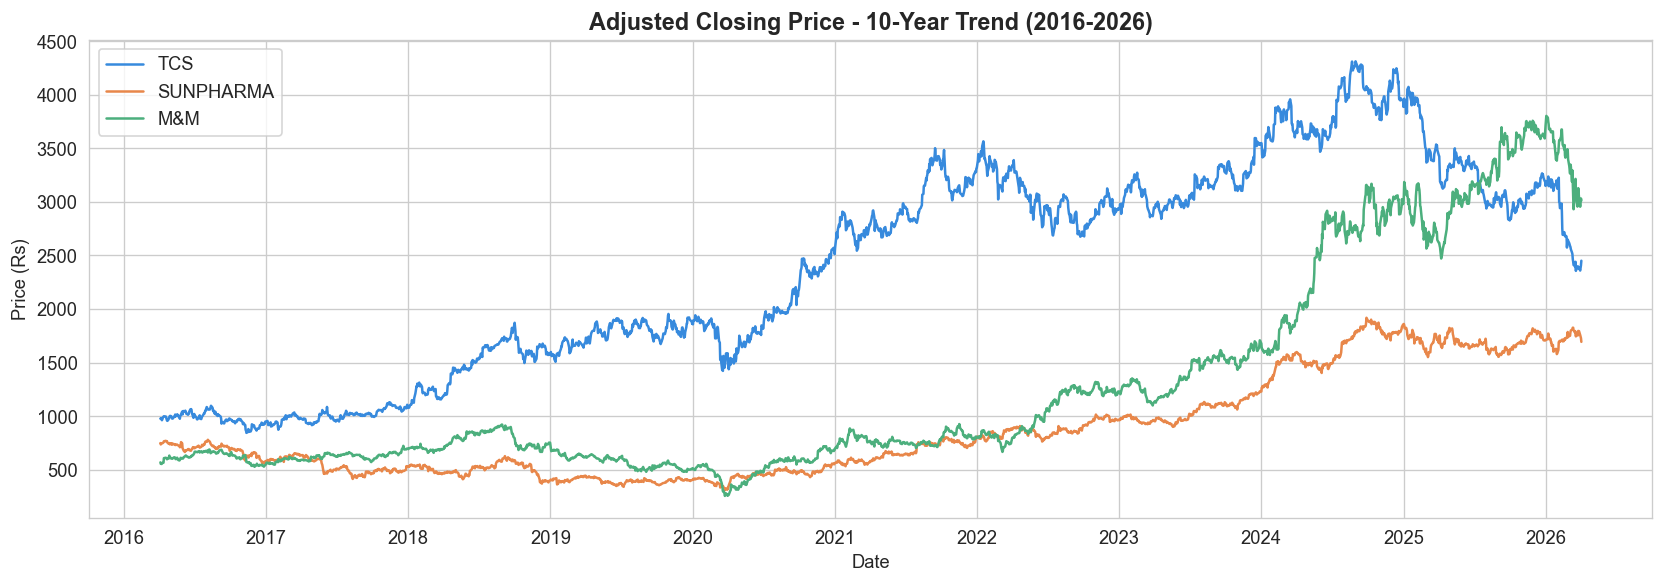

In [26]:
stocks = [
    (tcs, 'TCS',       COLORS['TCS']),
    (sun, 'SUNPHARMA', COLORS['SUNPHARMA']),
    (mm,  'M&M',       COLORS['M&M']),
]

fig, ax = plt.subplots(figsize=(14, 5))
for df, name, col in stocks:
    ax.plot(df['date'], df['adj_close'], label=name, color=col, linewidth=1.5)
ax.set_title('Adjusted Closing Price - 10-Year Trend (2016-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (Rs)')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, '01_price_trend.png'))
plt.show()

### Chart 2 — Normalised Performance (Base = 100)  *(Answers BQ1)*

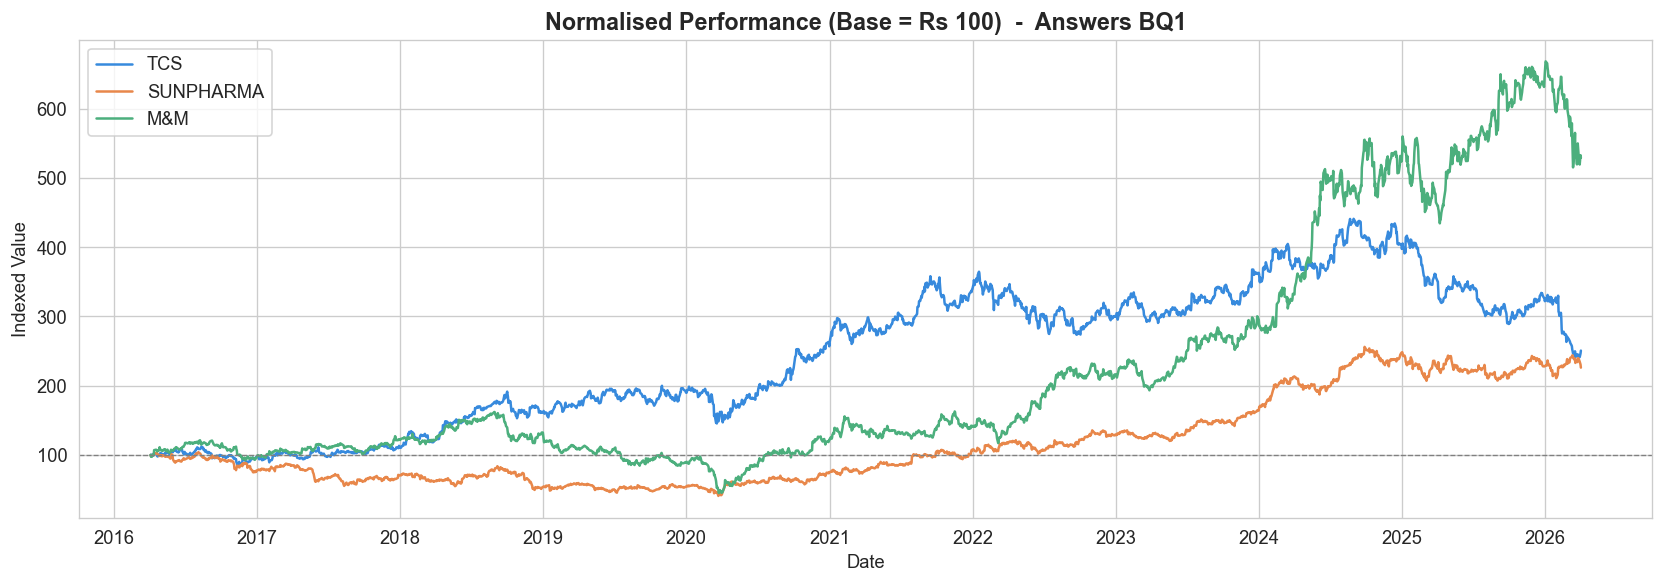

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))
for df, name, col in stocks:
    norm = df['adj_close'] / df['adj_close'].iloc[0] * 100
    ax.plot(df['date'], norm, label=name, color=col, linewidth=1.5)
ax.axhline(100, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Normalised Performance (Base = Rs 100)  -  Answers BQ1', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Indexed Value')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, '02_normalised_performance.png'))
plt.show()

### Chart 3 — Risk vs Return Scatter  *(Answers BQ2 & BQ5)*

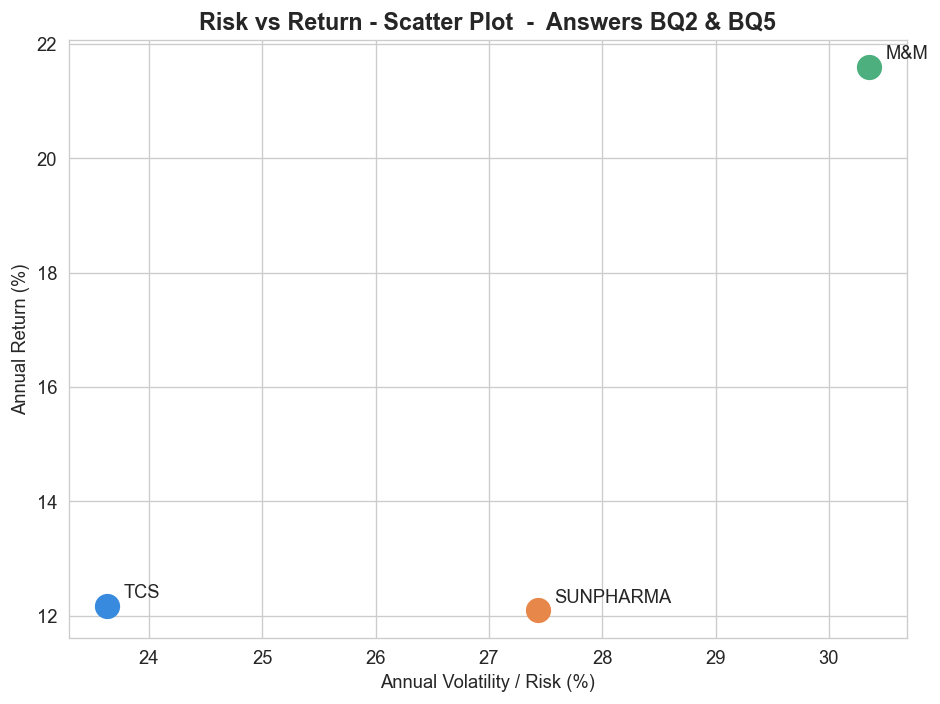

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
for _, row in results.iterrows():
    ax.scatter(row['Annual Volatility (%)'], row['Annual Return (%)'],
               color=COLORS.get(row.name, 'grey'), s=200, zorder=5)
    ax.annotate(row.name,
                (row['Annual Volatility (%)'], row['Annual Return (%)']),
                textcoords='offset points', xytext=(10, 5), fontsize=11)
ax.set_xlabel('Annual Volatility / Risk (%)')
ax.set_ylabel('Annual Return (%)')
ax.set_title('Risk vs Return - Scatter Plot  -  Answers BQ2 & BQ5', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, '03_risk_vs_return.png'))
plt.show()

### Chart 4 — Sharpe Ratio Comparison  *(Answers BQ3)*

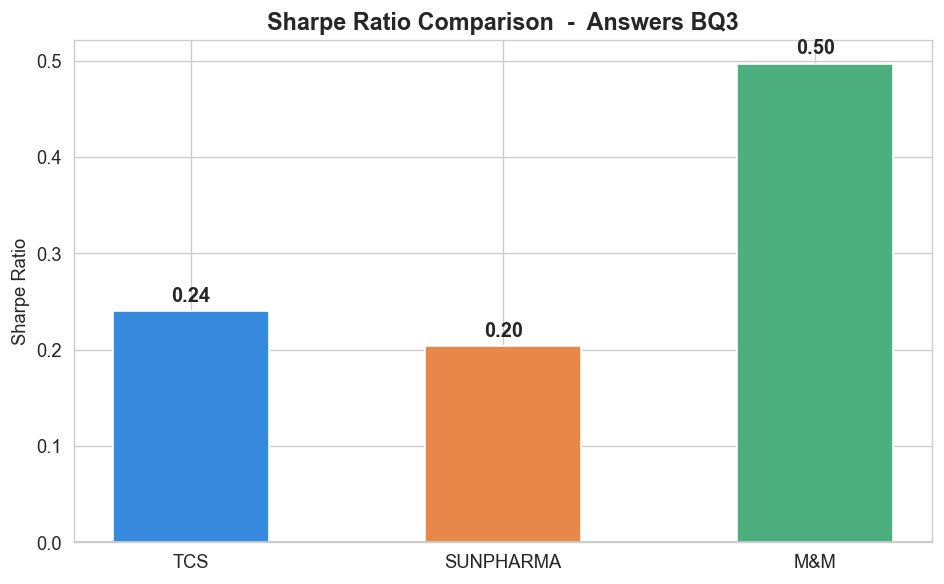

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
companies = results.index.tolist()
sharpes   = results['Sharpe Ratio'].tolist()
bars = ax.bar(companies, sharpes, color=[COLORS.get(c, 'grey') for c in companies], width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Sharpe Ratio Comparison  -  Answers BQ3', fontsize=14, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, '04_sharpe_ratio.png'))
plt.show()

### Chart 5 — Daily Return Distributions  *(Answers BQ1 & BQ2)*

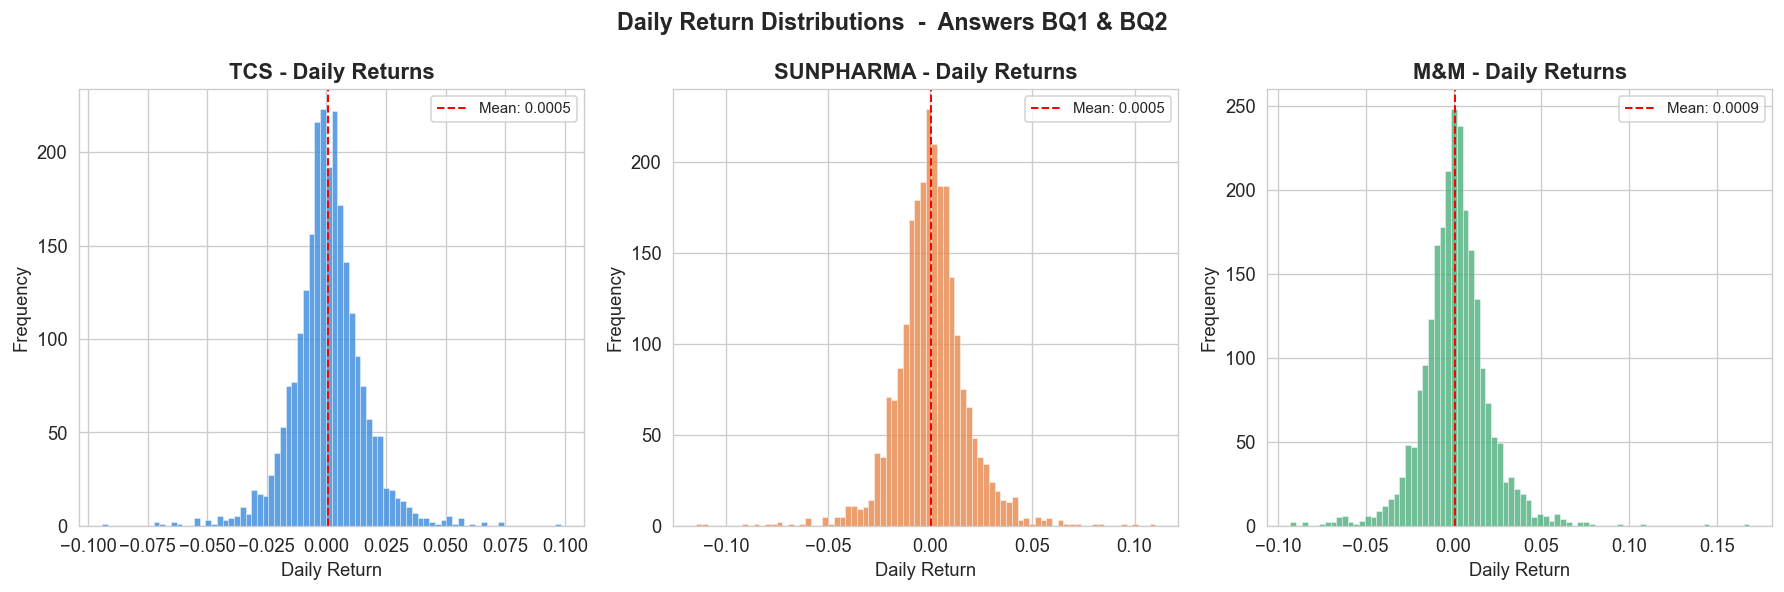

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (df, name, col) in zip(axes, stocks):
    r = df['daily_return'].dropna()
    ax.hist(r, bins=80, color=col, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(r.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {r.mean():.4f}')
    ax.set_title(f'{name} - Daily Returns', fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
fig.suptitle('Daily Return Distributions  -  Answers BQ1 & BQ2', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, '05_return_distributions.png'))
plt.show()

### Chart 6 — Rolling 30-Day Volatility  *(Answers BQ2)*

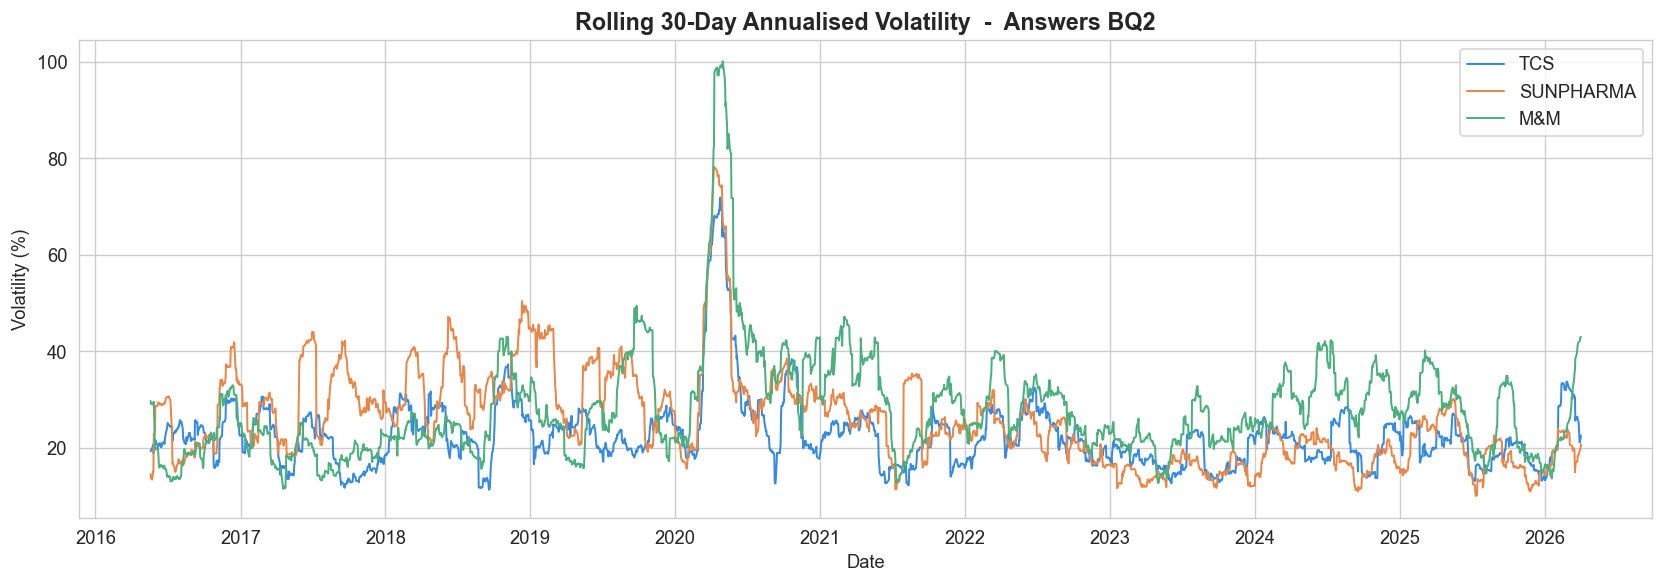

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))
for df, name, col in stocks:
    roll_vol = df['daily_return'].rolling(30).std() * np.sqrt(252) * 100
    ax.plot(df['date'], roll_vol, label=name, color=col, linewidth=1.2)
ax.set_title('Rolling 30-Day Annualised Volatility  -  Answers BQ2', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (%)')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, '06_rolling_volatility.png'))
plt.show()

### Chart 7 — Maximum Drawdown  *(Answers BQ2)*

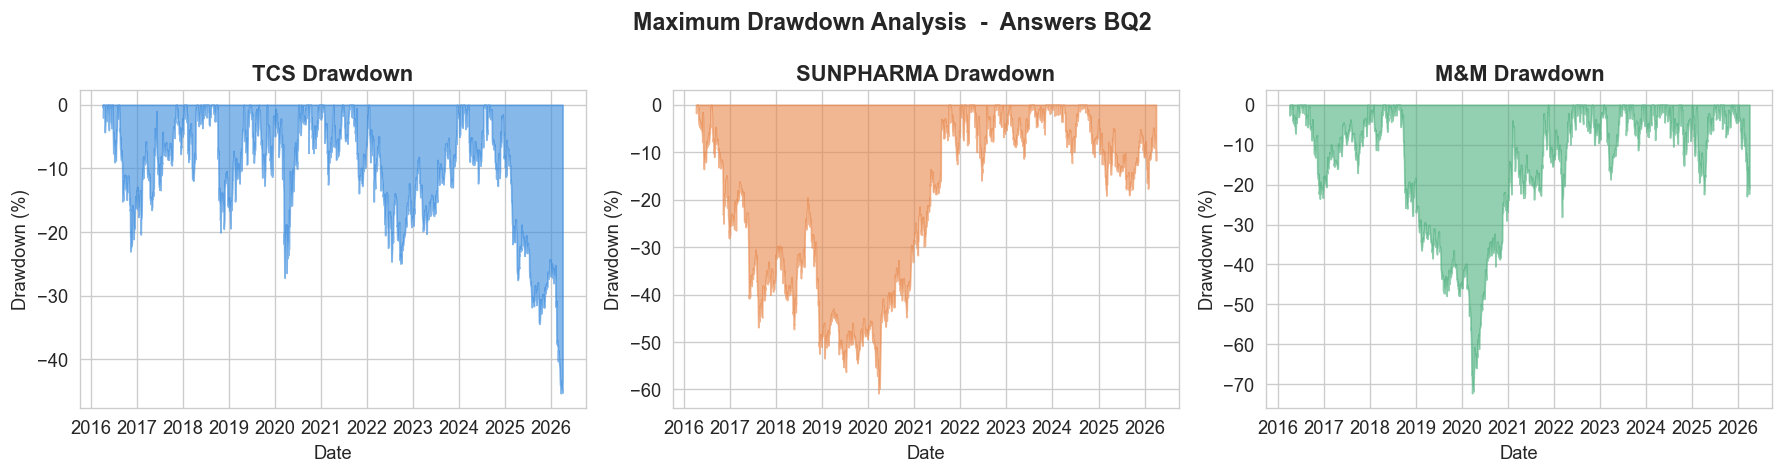

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (df, name, col) in zip(axes, stocks):
    roll_max = df['adj_close'].cummax()
    dd = (df['adj_close'] - roll_max) / roll_max * 100
    ax.fill_between(df['date'], dd, 0, color=col, alpha=0.6)
    ax.set_title(f'{name} Drawdown', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Drawdown (%)')
fig.suptitle('Maximum Drawdown Analysis  -  Answers BQ2', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, '07_drawdown.png'))
plt.show()

### Chart 8 — Correlation Heatmap  *(Answers BQ4)*

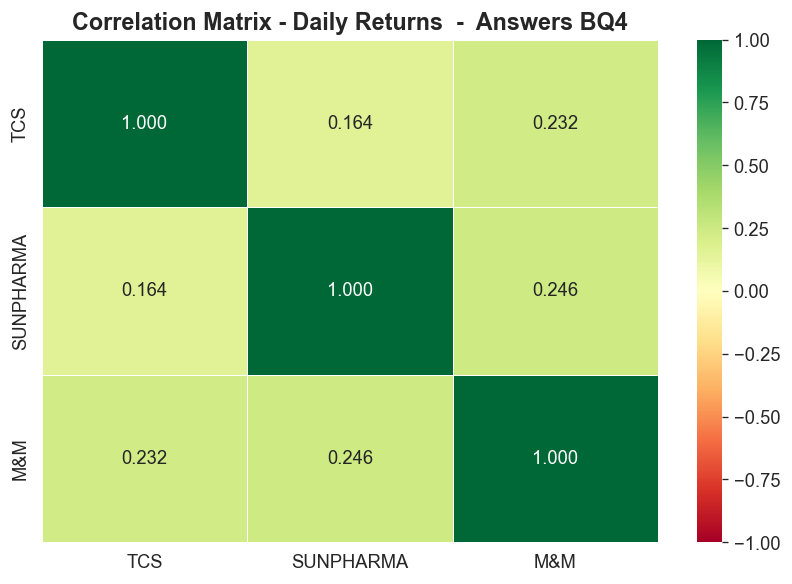


Correlation Matrix:


,TCS,SUNPHARMA,M&M
TCS,1.000000,0.163883,0.231780
SUNPHARMA,0.163883,1.000000,0.246367
M&M,0.231780,0.246367,1.000000


In [33]:
combined = pd.DataFrame({
    'TCS'      : tcs['daily_return'],
    'SUNPHARMA': sun['daily_return'],
    'M&M'      : mm['daily_return'],
}).dropna()
corr = combined.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix - Daily Returns  -  Answers BQ4', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, '08_correlation_heatmap.png'))
plt.show()

print("\nCorrelation Matrix:")
corr

### Chart 9 — Positive vs Negative Trading Days  *(Answers BQ1)*

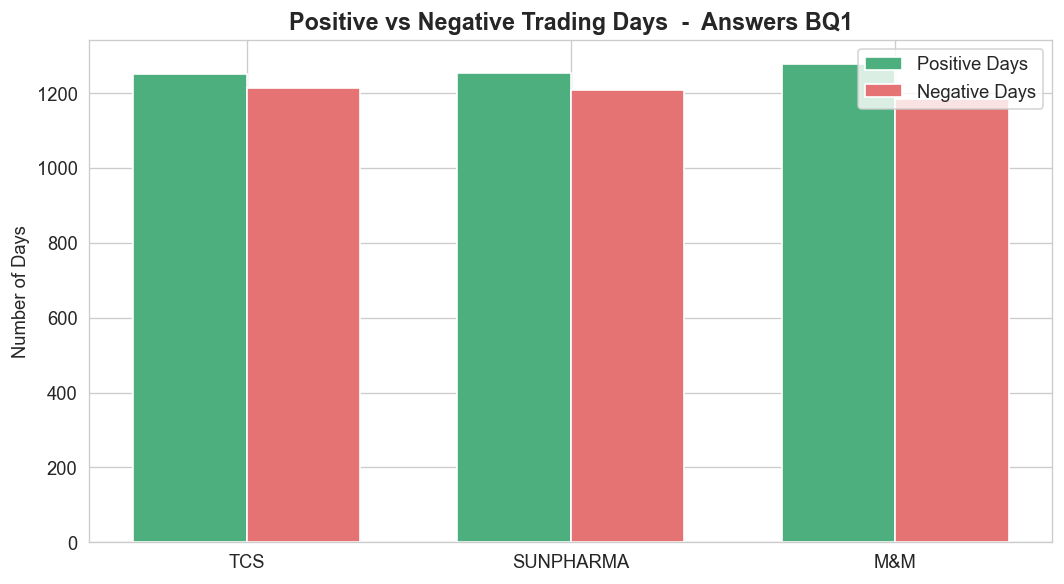

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results))
w = 0.35
pos = results['Positive Days'].tolist()
neg = results['Negative Days'].tolist()
b1 = ax.bar(x - w/2, pos, w, label='Positive Days', color='#4CAF7D')
b2 = ax.bar(x + w/2, neg, w, label='Negative Days', color='#E57373')
ax.set_xticks(x)
ax.set_xticklabels(results.index)
ax.set_title('Positive vs Negative Trading Days  -  Answers BQ1', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Days')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, '09_pos_neg_days.png'))
plt.show()

### Chart 10 — Cumulative Return  *(Answers BQ1 & BQ5)*

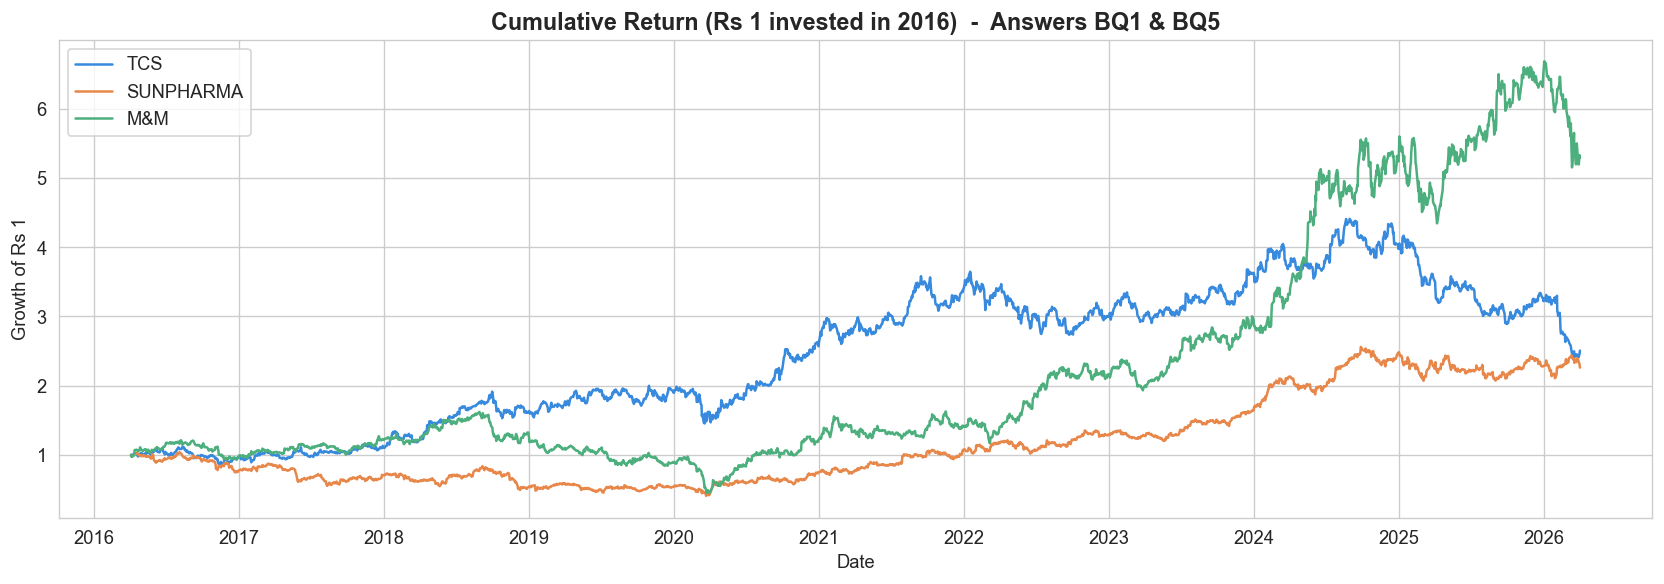

In [35]:
fig, ax = plt.subplots(figsize=(14, 5))
for df, name, col in stocks:
    cum = (1 + df['daily_return'].fillna(0)).cumprod()
    ax.plot(df['date'], cum, label=name, color=col, linewidth=1.5)
ax.set_title('Cumulative Return (Rs 1 invested in 2016)  -  Answers BQ1 & BQ5', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of Rs 1')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, '10_cumulative_return.png'))
plt.show()

### Chart 11 — Final Summary Dashboard

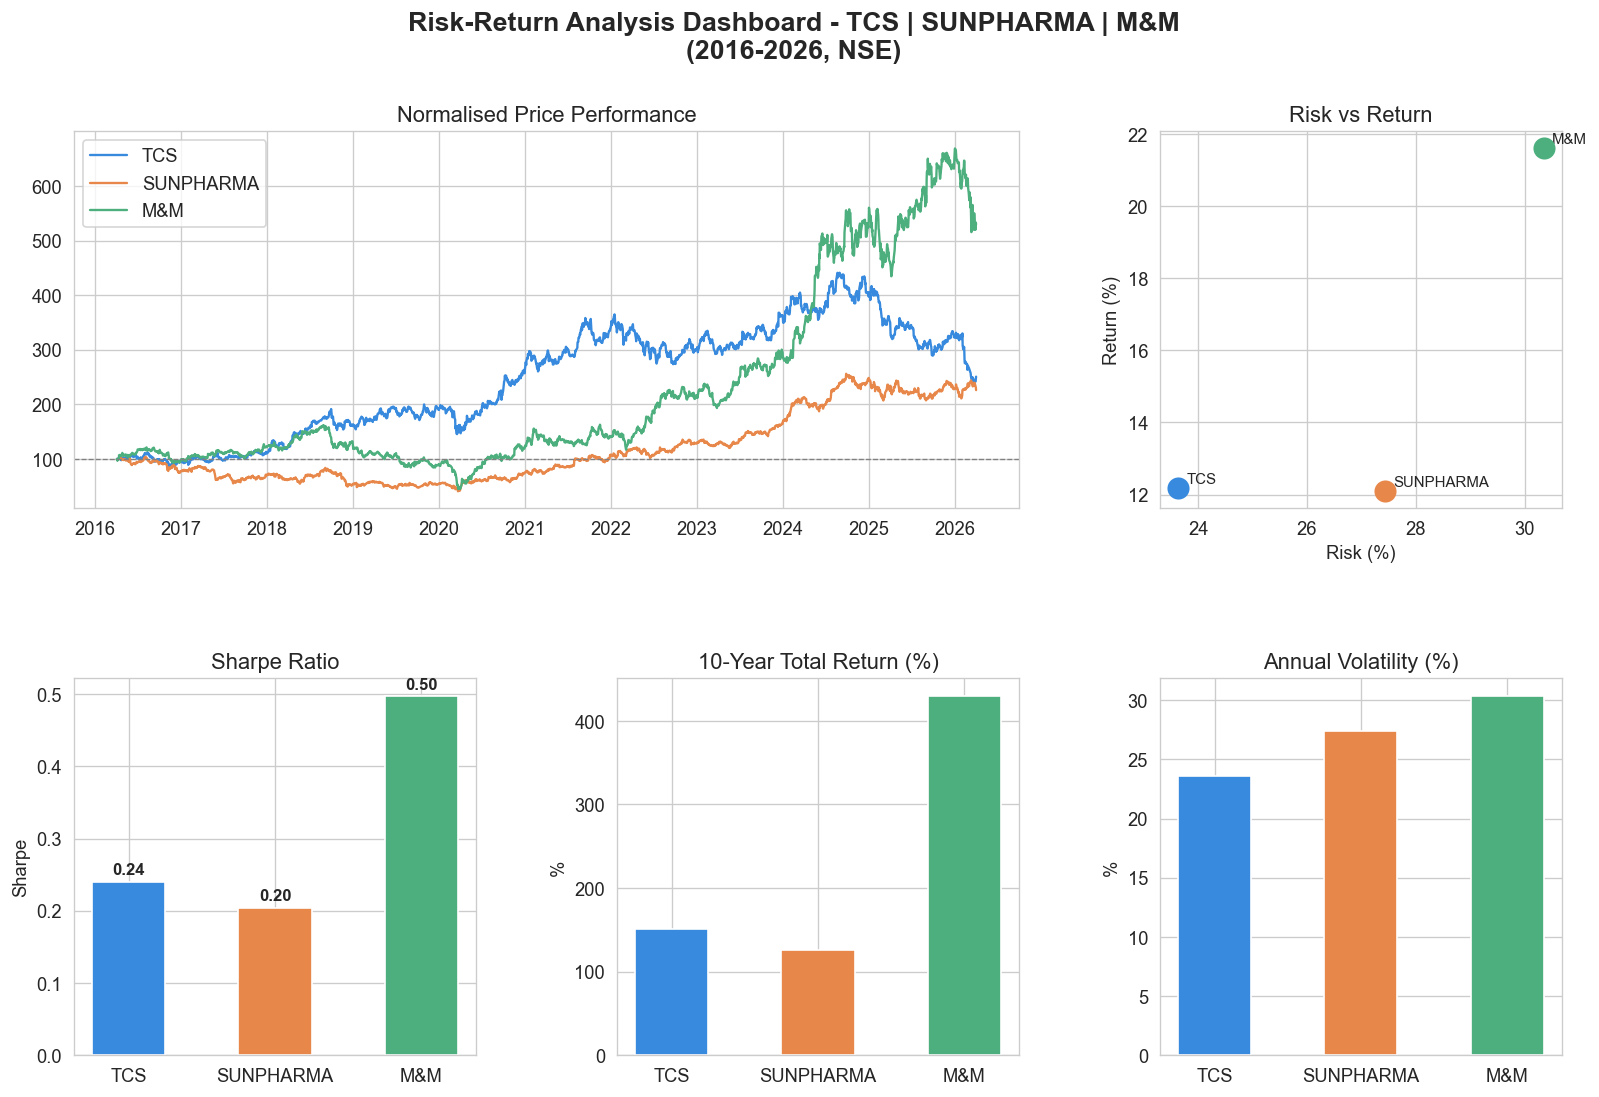

11 charts saved to /charts/


In [36]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Risk-Return Analysis Dashboard - TCS | SUNPHARMA | M&M\n(2016-2026, NSE)',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
for df, name, col in stocks:
    norm = df['adj_close'] / df['adj_close'].iloc[0] * 100
    ax1.plot(df['date'], norm, label=name, color=col, linewidth=1.4)
ax1.axhline(100, color='grey', linestyle='--', linewidth=0.8)
ax1.set_title('Normalised Price Performance')
ax1.legend()

ax2 = fig.add_subplot(gs[0, 2])
for _, row in results.iterrows():
    ax2.scatter(row['Annual Volatility (%)'], row['Annual Return (%)'],
                color=COLORS.get(row.name, 'grey'), s=150, zorder=5)
    ax2.annotate(row.name, (row['Annual Volatility (%)'], row['Annual Return (%)']),
                 xytext=(5, 3), textcoords='offset points', fontsize=9)
ax2.set_xlabel('Risk (%)')
ax2.set_ylabel('Return (%)')
ax2.set_title('Risk vs Return')

ax3 = fig.add_subplot(gs[1, 0])
bars = ax3.bar(results.index, results['Sharpe Ratio'],
               color=[COLORS.get(c, 'grey') for c in results.index], width=0.5)
for bar, val in zip(bars, results['Sharpe Ratio']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
ax3.set_title('Sharpe Ratio')
ax3.set_ylabel('Sharpe')

ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(results.index, results['Total Return (%)'],
        color=[COLORS.get(c, 'grey') for c in results.index], width=0.5)
ax4.set_title('10-Year Total Return (%)')
ax4.set_ylabel('%')

ax5 = fig.add_subplot(gs[1, 2])
ax5.bar(results.index, results['Annual Volatility (%)'],
        color=[COLORS.get(c, 'grey') for c in results.index], width=0.5)
ax5.set_title('Annual Volatility (%)')
ax5.set_ylabel('%')

fig.savefig(os.path.join(CHARTS_DIR, '11_summary_dashboard.png'), bbox_inches='tight')
plt.show()

print("11 charts saved to /charts/")

---
## Step 8: Save Results to CSV

In [18]:
os.makedirs('report', exist_ok=True)
results.to_csv('report/results_summary.csv')
print("report/results_summary.csv saved")
results

report/results_summary.csv saved


,Annual Return (%),Annual Volatility (%),Sharpe Ratio,Max Drawdown (%),Total Return (%),Positive Days,Negative Days
Stock,,,,,,,
TCS,12.17,23.63,0.240,-45.36,150.73,1250,1214
SUNPHARMA,12.09,27.43,0.204,-60.80,126.15,1254,1209
M&M,21.60,30.35,0.497,-72.28,429.54,1279,1185


---
## Step 9: Final Conclusions

In [19]:
print("-" * 60)
print(f"  Best Risk-Adjusted Return : {best_sharpe} (Sharpe = {results.loc[best_sharpe,'Sharpe Ratio']})")
print(f"  Highest Total Return      : {results['Total Return (%)'].idxmax()} "
      f"({results['Total Return (%)'].max():.1f}%)")
print(f"  Lowest Volatility         : {lowest_risk} "
      f"({results.loc[lowest_risk,'Annual Volatility (%)']:.1f}%)")
print(f"  Conservative Investor Rec : {lowest_risk}")
print(f"  Aggressive Investor Rec   : {results['Annual Return (%)'].idxmax()}")
print("-" * 60)

------------------------------------------------------------
  Best Risk-Adjusted Return : M&M (Sharpe = 0.497)
  Highest Total Return      : M&M (429.5%)
  Lowest Volatility         : TCS (23.6%)
  Conservative Investor Rec : TCS
  Aggressive Investor Rec   : M&M
------------------------------------------------------------

Pipeline complete! All files saved in /charts/ and /report/
